In [1]:
import warnings 
warnings.filterwarnings('ignore')

## K-Nearest-Neighbors

KNN falls in the supervised learning family of algorithms. Informally, this means that we are given a labelled dataset consiting of training observations (x,y) and would like to capture the relationship between x and y. More formally, our goal is to learn a function h:X→Y so that given an unseen observation x, h(x) can confidently predict the corresponding output y.

In this module we will explore the inner workings of KNN, choosing the optimal K values and using KNN from scikit-learn.

## Overview

1.Read the problem statement.

2.Get the dataset.

3.Explore the dataset.

4.Pre-processing of dataset.

5.Visualization

6.Transform the dataset for building machine learning model.

7.Split data into train, test set.

7.Build Model.

8.Apply the model.

9.Evaluate the model.

10.Finding Optimal K value

11.Repeat 7,8,9 steps.

## Problem statement

### Dataset

The data set we’ll be using is the Iris Flower Dataset which was first introduced in 1936 by the famous statistician Ronald Fisher and consists of 50 observations from each of three species of Iris (Iris setosa, Iris virginica and Iris versicolor). Four features were measured from each sample: the length and the width of the sepals and petals.

**Attributes of the dataset:** https://archive.ics.uci.edu/ml/datasets/Iris

**Train the KNN algorithm to be able to distinguish the species from one another given the measurements of the 4 features.**

In [2]:
import numpy as np
import pandas as pd

# importing ploting libraries
import matplotlib.pyplot as plt   
#importing seaborn for statistical plots
import seaborn as sns
# To enable plotting graphs in Jupyter notebook
%matplotlib inline

In [3]:
colnames = ['sepal_len', 'sepal_wid', 'petal_len', 'petal_wid', 'class']
iris_df = pd.read_csv("iris.data", names= colnames)

## Question 1

Import the data set and print 10 random rows from the data set

In [4]:
iris_df.sample(n=10,random_state=8)

,sepal_len,sepal_wid,petal_len,petal_wid,class
4,5.0,3.6,1.4,0.2,Iris-setosa
29,4.7,3.2,1.6,0.2,Iris-setosa
27,5.2,3.5,1.5,0.2,Iris-setosa
141,6.9,3.1,5.1,2.3,Iris-virginica
65,6.7,3.1,4.4,1.4,Iris-versicolor
34,4.9,3.1,1.5,0.1,Iris-setosa
23,5.1,3.3,1.7,0.5,Iris-setosa
145,6.7,3.0,5.2,2.3,Iris-virginica
132,6.4,2.8,5.6,2.2,Iris-virginica
74,6.4,2.9,4.3,1.3,Iris-versicolor


## Data Pre-processing

## Question 2 - Estimating missing values

*Its not good to remove the records having missing values all the time. We may end up loosing some data points. So, we will have to see how to replace those missing values with some estimated values (median) *

In [5]:
iris_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
sepal_len    150 non-null float64
sepal_wid    150 non-null float64
petal_len    150 non-null float64
petal_wid    150 non-null float64
class        150 non-null object
dtypes: float64(4), object(1)
memory usage: 5.9+ KB


In [6]:
iris_df.shape

(150, 5)

In [7]:
iris_df.describe()

,sepal_len,sepal_wid,petal_len,petal_wid
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [8]:
#according to the above, all the minimum values are non zero, max values are non infinity.
#Hence there is no missing value
#Still fill the missing data, as per the assignment question

In [9]:
iris_df['sepal_len']=iris_df['sepal_len'].replace(0, iris_df['sepal_len'].median())
iris_df['sepal_wid']=iris_df['sepal_wid'].replace(0, iris_df['sepal_wid'].median())
iris_df['petal_len']=iris_df['petal_len'].replace(0, iris_df['petal_len'].median())
iris_df['petal_wid']=iris_df['petal_wid'].replace(0, iris_df['petal_wid'].median())
iris_df.head()

,sepal_len,sepal_wid,petal_len,petal_wid,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


## Question 3 - Dealing with categorical data

Change all the classes to numericals (0to2).

In [10]:
#convert object to numeric
df = pd.get_dummies(iris_df)

In [11]:
#convert class object into category
iris_df['class'] = iris_df['class'].astype('category')
iris_df['class'] = iris_df['class'].cat.codes
iris_df

,sepal_len,sepal_wid,petal_len,petal_wid,class
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
5,5.4,3.9,1.7,0.4,0
6,4.6,3.4,1.4,0.3,0
7,5.0,3.4,1.5,0.2,0
8,4.4,2.9,1.4,0.2,0
9,4.9,3.1,1.5,0.1,0


In [12]:
iris_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
sepal_len    150 non-null float64
sepal_wid    150 non-null float64
petal_len    150 non-null float64
petal_wid    150 non-null float64
class        150 non-null int8
dtypes: float64(4), int8(1)
memory usage: 4.9 KB


## Question 4

*Observe the association of each independent variable with target variable and drop variables from feature set having correlation in range -0.1 to 0.1 with target variable.*

In [13]:
iris_df.corr()

,sepal_len,sepal_wid,petal_len,petal_wid,class
sepal_len,1.000000,-0.109369,0.871754,0.817954,0.782561
sepal_wid,-0.109369,1.000000,-0.420516,-0.356544,-0.419446
petal_len,0.871754,-0.420516,1.000000,0.962757,0.949043
petal_wid,0.817954,-0.356544,0.962757,1.000000,0.956464
class,0.782561,-0.419446,0.949043,0.956464,1.000000


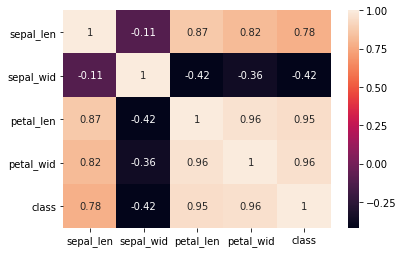

In [14]:
sns.heatmap(iris_df.corr(), annot=True)

In [15]:
df.corr()

,sepal_len,sepal_wid,petal_len,petal_wid,class_Iris-setosa,class_Iris-versicolor,class_Iris-virginica
sepal_len,1.000000,-0.109369,0.871754,0.817954,-0.717416,0.079396,0.638020
sepal_wid,-0.109369,1.000000,-0.420516,-0.356544,0.595601,-0.464700,-0.130901
petal_len,0.871754,-0.420516,1.000000,0.962757,-0.922688,0.201587,0.721102
petal_wid,0.817954,-0.356544,0.962757,1.000000,-0.887510,0.118376,0.769134
class_Iris-setosa,-0.717416,0.595601,-0.922688,-0.887510,1.000000,-0.500000,-0.500000
class_Iris-versicolor,0.079396,-0.464700,0.201587,0.118376,-0.500000,1.000000,-0.500000
class_Iris-virginica,0.638020,-0.130901,0.721102,0.769134,-0.500000,-0.500000,1.000000


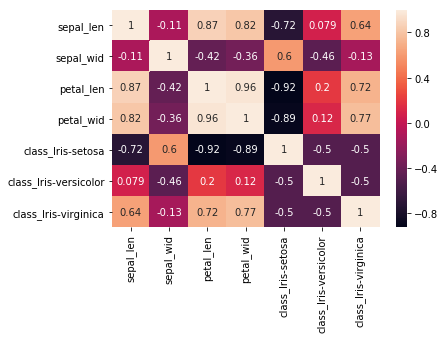

In [16]:
sns.heatmap(df.corr(), annot=True)

In [17]:
#no variable feature is falling between correlation of -0.1 to 0.1. Hence not dropping any variable feature

#ignore below
#import pylab as pl
#iris_df.drop('class' ,axis=1).hist(bins=30, figsize=(9,9))
#pl.suptitle("Histogram for each numeric input variable")
#plt.savefig('iris')
#plt.show()

## Question 5

*Observe the independent variables variance and drop such variables having no variance or almost zero variance(variance < 0.1). They will be having almost no influence on the classification.*

In [18]:
iris_df.var()

sepal_len    0.685694
sepal_wid    0.188004
petal_len    3.113179
petal_wid    0.582414
class        0.671141
dtype: float64

In [19]:
df.var()

sepal_len                0.685694
sepal_wid                0.188004
petal_len                3.113179
petal_wid                0.582414
class_Iris-setosa        0.223714
class_Iris-versicolor    0.223714
class_Iris-virginica     0.223714
dtype: float64

In [20]:
df.loc[:, df.var() < .1]

""
0
1
2
3
4
5
6
7
8
9


In [21]:
#no independent variables variance are having no variance or almost zero variance (<0.1).
#Hence not dropping any independent variable

## Question 6

*Plot the scatter matrix for all the variables.*

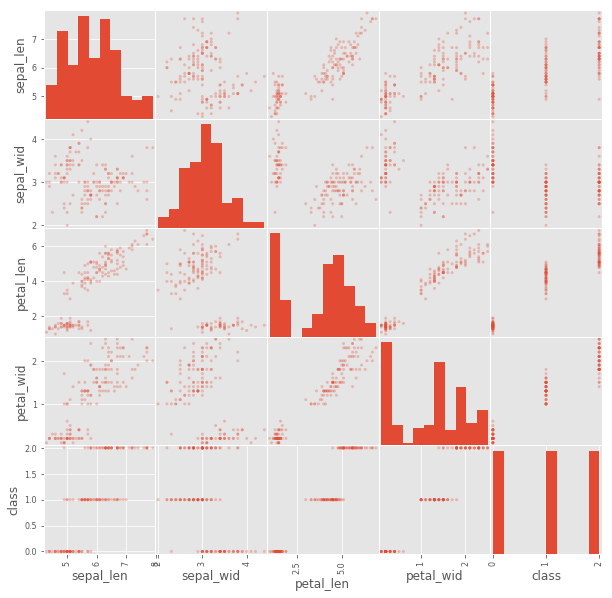

In [22]:
plt.style.use('ggplot')
pd.scatter_matrix(iris_df, alpha=0.3, figsize=(10, 10))
plt.show()

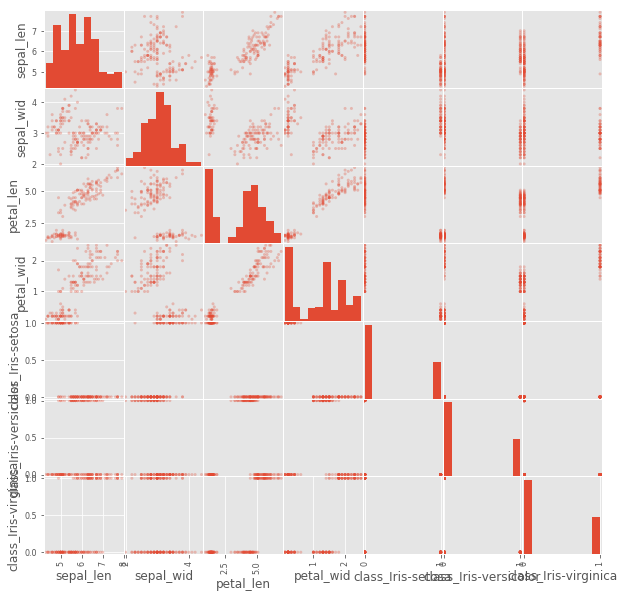

In [23]:
plt.style.use('ggplot')
pd.scatter_matrix(df, alpha=0.3, figsize=(10, 10))
plt.show()

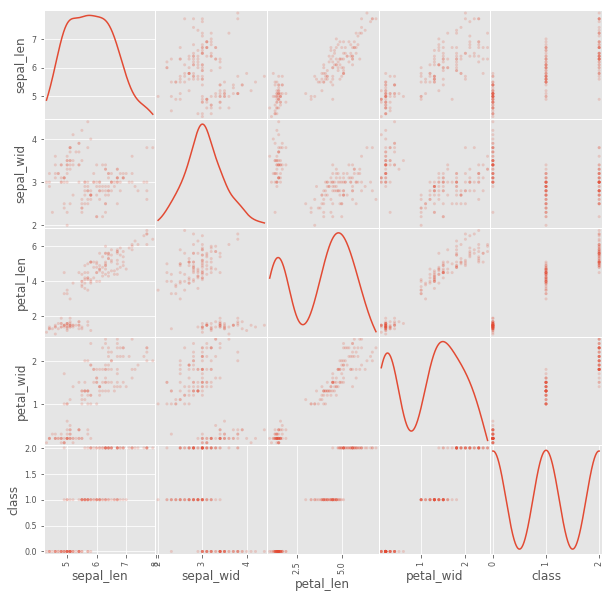

In [24]:
pd.scatter_matrix(iris_df, alpha=0.2, figsize=(10, 10), diagonal='kde')
plt.show()

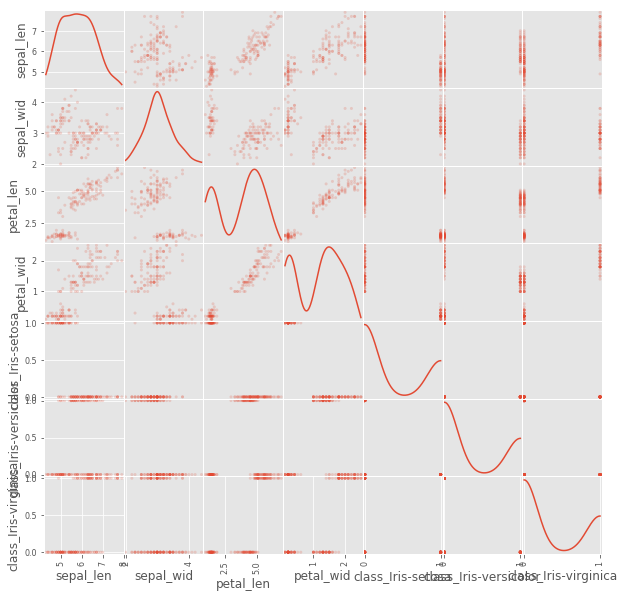

In [25]:
pd.scatter_matrix(df, alpha=0.2, figsize=(10, 10), diagonal='kde')
plt.show()

## Split the dataset into training and test sets

## Question 7

*Split the dataset into training and test sets with 80-20 ratio.*

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score, auc, roc_curve
from sklearn.feature_extraction.text import CountVectorizer

from sklearn.model_selection import cross_val_score

#vec = CountVectorizer() 
X = iris_df.drop("class", axis=1)
y = iris_df["class"]
test_size = 0.2
seed = 7
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

## Question 8 - Model

*Build the model and train and test on training and test sets respectively using **scikit-learn**. Print the Accuracy of the model with different values of **k=3,5,9**.*

**Hint:** For accuracy you can check **accuracy_score()** in scikit-learn

In [27]:
def KNNModelPerformanceAnalysis(model):
    model.fit(X_train, y_train)
    ### Unoptimized probability threshold based performance numbers
    # Train accuracy numbers
    trainPreds = model.predict(X_train)
    trainAccuracy = accuracy_score(y_train, trainPreds)
    trainRecall = recall_score(y_train, trainPreds, average='weighted')
    trainPrecision = precision_score(y_train, trainPreds, average='weighted')
    trainF1score = f1_score(y_train, trainPreds, average='weighted')
    trainCVScores = cross_val_score(knn, X_train, y_train, cv=10, scoring='accuracy')
    trainResults=[X_train.shape[0], trainAccuracy, trainRecall, trainPrecision, trainF1score, trainCVScores.mean()]
    
    
    # Test accuracy numbers
    testPreds = model.predict(X_test)
    testAccuracy = accuracy_score(y_test, testPreds)
    testRecall = recall_score(y_test, testPreds, average='weighted')
    testPrecision = precision_score(y_test, testPreds, average='weighted')
    testF1score = f1_score(y_test, testPreds, average='weighted')
    testCVScores = cross_val_score(knn, X_test, y_test, cv=10, scoring='accuracy')
    testResults=[X_test.shape[0], testAccuracy, testRecall, testPrecision, testF1score, testCVScores.mean()]
    
    
    resultsDf = pd.DataFrame( index=["dataSize", "accuracy", "recall", "precision", "f1_score", "CV_score"])
    resultsDf['unOptimalTrainResults'] = trainResults
    resultsDf['unOptimalTestResults'] = testResults
    
    return resultsDf

In [28]:
#square root of 150 (total size) . hence no of neighbors = 13
knn = KNeighborsClassifier(n_neighbors= 13)
KNNModelPerformanceAnalysis(knn)

,unOptimalTrainResults,unOptimalTestResults
dataSize,120.000000,30.000000
accuracy,0.991667,0.900000
recall,0.991667,0.900000
precision,0.991875,0.902525
f1_score,0.991664,0.900000
CV_score,0.991667,0.681667


In [29]:
#no of neighbors = 3
knn = KNeighborsClassifier(n_neighbors= 3)
KNNModelPerformanceAnalysis(knn)

,unOptimalTrainResults,unOptimalTestResults
dataSize,120.000000,30.000000
accuracy,0.975000,0.900000
recall,0.975000,0.900000
precision,0.975191,0.901795
f1_score,0.974992,0.899619
CV_score,0.972576,0.946667


In [30]:
#no of neighbors = 5
knn = KNeighborsClassifier(n_neighbors= 5)
KNNModelPerformanceAnalysis(knn)

,unOptimalTrainResults,unOptimalTestResults
dataSize,120.000000,30.000000
accuracy,0.983333,0.900000
recall,0.983333,0.900000
precision,0.984146,0.901795
f1_score,0.983316,0.899619
CV_score,0.981667,0.930000


In [31]:
#no of neighbors = 9
knn = KNeighborsClassifier(n_neighbors= 9)
KNNModelPerformanceAnalysis(knn)

,unOptimalTrainResults,unOptimalTestResults
dataSize,120.000000,30.000000
accuracy,0.991667,0.900000
recall,0.991667,0.900000
precision,0.991875,0.902525
f1_score,0.991664,0.900000
CV_score,0.983974,0.793333


## Question 9 - Cross Validation

Run the KNN with no of neighbours to be 1,3,5..19 and *Find the **optimal number of neighbours** from the above list using the Mis classification error

In [32]:
# creating odd list of K for KNN
# CV score in the output gives the CrossValidation Score
noOfNeighbors = np.arange(1, 20, 2)
print ('noNeighbors:' , noOfNeighbors)

# empty list that will hold cv scores
cv_scores = []

# perform 10-fold cross validation
for k in noOfNeighbors:
    print()
    print("No_of_Neighbors:", k)
    knn = KNeighborsClassifier(n_neighbors=k)
    resultsDf = KNNModelPerformanceAnalysis(knn)
    print (resultsDf)
    cv_scores.append(resultsDf['unOptimalTrainResults'].CV_score)

noNeighbors: [ 1  3  5  7  9 11 13 15 17 19]

No_of_Neighbors: 1
           unOptimalTrainResults  unOptimalTestResults
dataSize              120.000000             30.000000
accuracy                1.000000              0.900000
recall                  1.000000              0.900000
precision               1.000000              0.901795
f1_score                1.000000              0.899619
CV_score                0.972576              0.896667

No_of_Neighbors: 3
           unOptimalTrainResults  unOptimalTestResults
dataSize              120.000000             30.000000
accuracy                0.975000              0.900000
recall                  0.975000              0.900000
precision               0.975191              0.901795
f1_score                0.974992              0.899619
CV_score                0.972576              0.946667

No_of_Neighbors: 5
           unOptimalTrainResults  unOptimalTestResults
dataSize              120.000000             30.000000
accuracy       

In [33]:
# changing to misclassification error
MSE = [1 - x for x in cv_scores]

# determining best k
optimal_k = noOfNeighbors[MSE.index(min(MSE))]
print ("The optimal number of neighbors is", optimal_k)

The optimal number of neighbors is 13


Hint:

Misclassification error (MSE) = 1 - Test accuracy score. Calculated MSE for each model with neighbours = 1,3,5...19 and find the model with lowest MSE

## Question 10

*Plot misclassification error vs k (with k value on X-axis) using matplotlib.*

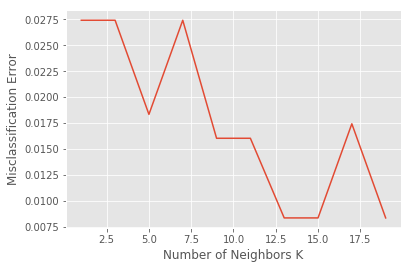

In [34]:
# plot misclassification error vs k
plt.plot(noOfNeighbors, MSE)
plt.xlabel('Number of Neighbors K')
plt.ylabel('Misclassification Error')
plt.show()

# Naive Bayes with Iris Data

In [35]:
#Load all required library
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline
from sklearn import datasets
from sklearn.decomposition import PCA
from sklearn.naive_bayes import GaussianNB, BernoulliNB, MultinomialNB

### Slice  Iris data set for Independent variables and dependent variables
#### Please note 'Species' is my dependent variables, name it y and independent set data as X

In [36]:
colnames = ['sepal_len', 'sepal_wid', 'petal_len', 'petal_wid', 'class']
iris_df = pd.read_csv("iris.data", names= colnames)

x = iris_df.drop("class", axis=1)
y = iris_df["class"]

In [37]:
#Check the dataset
#print(x)

In [38]:
#print(y)

# Question 11 
Find the distribution of target variable (Class)

And, Plot the distribution of target variable using histogram

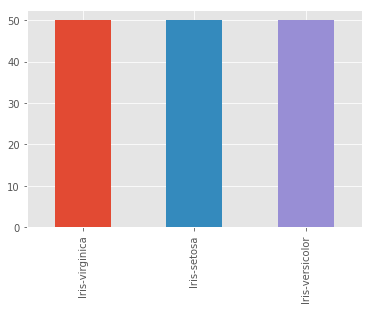

In [39]:
iris_df['class'].value_counts().plot.bar()

([array([0.16296296, 0.37037037, 0.16296296, 0.04444444, 0.        ,
         0.        , 0.        , 0.        ]),
  array([0.16296296, 0.42962963, 0.34074074, 0.25185185, 0.17777778,
         0.1037037 , 0.01481481, 0.        ]),
  array([0.16296296, 0.44444444, 0.35555556, 0.35555556, 0.45925926,
         0.25185185, 0.1037037 , 0.08888889])],
 array([4.3 , 4.75, 5.2 , 5.65, 6.1 , 6.55, 7.  , 7.45, 7.9 ]),
 <a list of 3 Lists of Patches objects>)

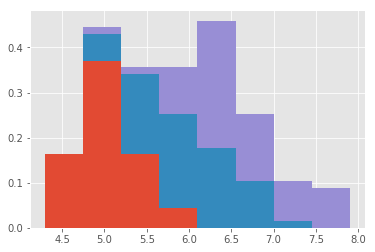

In [40]:
x = [iris_df['sepal_len'][iris_df['class']== sp_name] for sp_name in ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']]
plt.hist(x, 8, density=True, histtype='bar', stacked=True)

[]

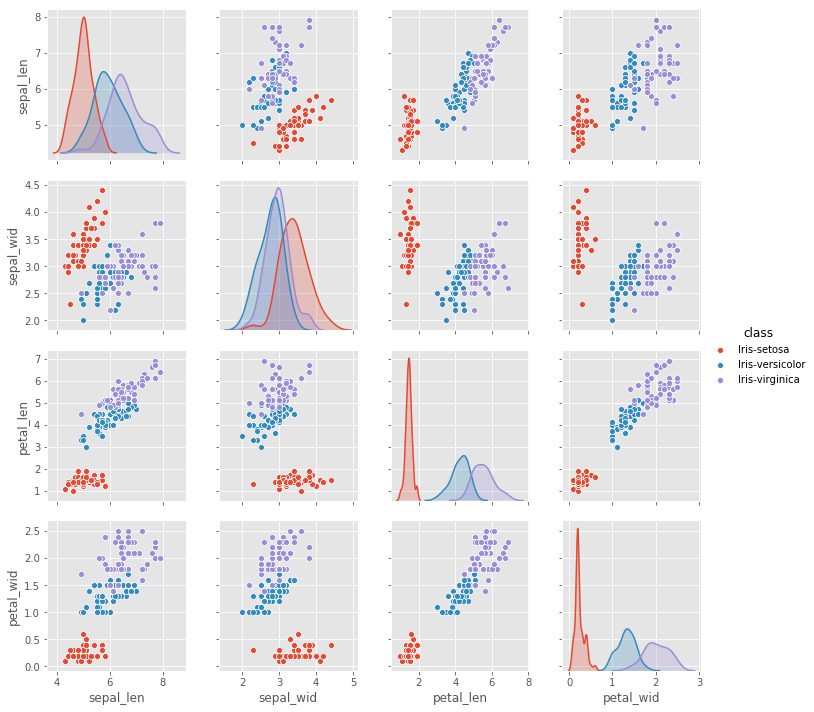

In [41]:
g = sns.pairplot(iris_df, hue="class")
ax = g.diag_axes[0]
ax.plot()

In [42]:
iris_df.head()

,sepal_len,sepal_wid,petal_len,petal_wid,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [43]:
#Drop Id variable from data
#There is no Id variable in data

### Question 12 
Find Correlation among all variables and give your insights 

In [44]:
#Please note, it's Require to remove correlated features because they are voted twice in the model and 
## it can lead to over inflating importance.We will ignore it here

In [45]:
iris_df.corr()

,sepal_len,sepal_wid,petal_len,petal_wid
sepal_len,1.000000,-0.109369,0.871754,0.817954
sepal_wid,-0.109369,1.000000,-0.420516,-0.356544
petal_len,0.871754,-0.420516,1.000000,0.962757
petal_wid,0.817954,-0.356544,0.962757,1.000000


In [46]:
#Among the variables, sepal_len is highly correlated to petal_len and petal_wid.
#petal_len and petal_wid are also highly correlated
#sepal_wid is not much correlated with other variables

### Split data in Training and test set in 80:20.

In [47]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

#vec = CountVectorizer() 
X = iris_df.drop("class", axis=1)
y = iris_df["class"]
test_size = 0.2
seed = 7
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

In [48]:
X_mat = X.as_matrix()
X_mat.shape

(150, 4)

In [49]:
vif = [ variance_inflation_factor( X_mat, i ) for i in range( X_mat.shape[1] ) ]
vif

[264.7457109493044, 97.1116058338033, 173.96896536339727, 55.48868864572551]

In [50]:
vif_factors = pd.DataFrame()
vif_factors['column'] = list(X.columns)
vif_factors['vif'] = vif
vif_factors

,column,vif
0,sepal_len,264.745711
1,sepal_wid,97.111606
2,petal_len,173.968965
3,petal_wid,55.488689


In [51]:
Xcopy = X.copy()

In [52]:
Xcopy = Xcopy.drop('sepal_len', axis=1)

In [53]:
X_mat = Xcopy.as_matrix()
X_mat.shape
vif = [ variance_inflation_factor( X_mat, i ) for i in range( X_mat.shape[1] ) ]
vif_factors = pd.DataFrame()
vif_factors['column'] = list(Xcopy.columns)
vif_factors['vif'] = vif
vif_factors

,column,vif
0,sepal_wid,5.896727
1,petal_len,61.750178
2,petal_wid,42.917554


In [54]:
X1copy = Xcopy.copy()
X1copy = X1copy.drop('petal_len', axis=1)
X_mat = X1copy.as_matrix()
X_mat.shape
vif = [ variance_inflation_factor( X_mat, i ) for i in range( X_mat.shape[1] ) ]
vif_factors = pd.DataFrame()
vif_factors['column'] = list(X1copy.columns)
vif_factors['vif'] = vif
vif_factors

,column,vif
0,sepal_wid,2.897752
1,petal_wid,2.897752


In [55]:
#vif less than 10, so keep these features
#even  from correlation sepal_wid was not correlated with other features.
#Also from correlation petal_wid is highly correlated to petal_len and sepal_len. 
#Hence removing the related features, only sepal_wid and petal_wid remains

In [56]:
#convert class object into category
X_train, X_test, y_train, y_test = train_test_split(X1copy, y, test_size=test_size, random_state=seed)
model = KNeighborsClassifier(n_neighbors= 13)

model.fit(X_train, y_train)
### Unoptimized probability threshold based performance numbers
# Train accuracy numbers
trainPreds = model.predict(X_train)
trainAccuracy = accuracy_score(y_train, trainPreds)
trainRecall = recall_score(y_train, trainPreds, average='weighted')
trainPrecision = precision_score(y_train, trainPreds, average='weighted')
trainF1score = f1_score(y_train, trainPreds, average='weighted')
trainCVScores = cross_val_score(knn, X_train, y_train, cv=10, scoring='accuracy')
trainResults=[X_train.shape[0], trainAccuracy, trainRecall, trainPrecision, trainF1score, trainCVScores.mean()]
    
    
# Test accuracy numbers
testPreds = model.predict(X_test)
testAccuracy = accuracy_score(y_test, testPreds)
testRecall = recall_score(y_test, testPreds, average='weighted')
testPrecision = precision_score(y_test, testPreds, average='weighted')
testF1score = f1_score(y_test, testPreds, average='weighted')
testCVScores = cross_val_score(knn, X_test, y_test, cv=10, scoring='accuracy')
testResults=[X_test.shape[0], testAccuracy, testRecall, testPrecision, testF1score, testCVScores.mean()]
    
    
resultsDf = pd.DataFrame( index=["dataSize", "accuracy", "recall", "precision", "f1_score", "CV_score"])
resultsDf['unOptimalTrainResults'] = trainResults
resultsDf['unOptimalTestResults'] = testResults
    
resultsDf

,unOptimalTrainResults,unOptimalTestResults
dataSize,120.000000,30.000000
accuracy,0.975000,0.866667
recall,0.975000,0.866667
precision,0.975208,0.866667
f1_score,0.975000,0.866667
CV_score,0.974883,0.431667


In [57]:
#Multicollinearity might cause Predictive uncertainty. 
#Hence predicted values may be very far than the actual due to overfitting tendency with highly correlated features 
#In order to avoid it, use the VIF factor to identify which variable to be removed from the input.
#this helps in avoiding overfitting 

### Question 13 
Do Feature Scaling 

In [58]:
# Use StandardScaler or similar methods
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

s_sc = StandardScaler()
scaled_df = s_sc.fit_transform(X1copy)

In [59]:
#X_train_minmax=min_max.fit_transform(X_train[['sepal_wid', 'petal_wid']])
#X_test_minmax=min_max.fit_transform(X_test[['sepal_wid', 'petal_wid']])

test_size = 0.2
seed = 7
X_train, X_test, y_train, y_test = train_test_split(scaled_df, y, test_size=test_size, random_state=seed)

In [60]:
#Feature Scaling helps in normalising the data in a particular range and speeding up the calculations in an algorithm.
#Scaling helps in a better test accuracy since it avoids leaking of the test set information in to training set.
#Hence after scaling the accuracy is in test data prediction is  lesser compared to unscaled training set data based predictions
#This is observed from the below steps

### Question 14 
Train and Fit NaiveBayes Model

In [81]:
#X_train has negative numbers due to removal of unit by feature scaling 
#Hence normalize it to the absolute value. Now all the fetaures are unitless
#Multinomial NB does not accept negative numbers

In [62]:
temp = abs (X_train.min())
print(temp)
X_train = X_train + temp

2.438987252491841


In [63]:
#Fit the model
mnb=MultinomialNB()
mnb.fit(X_train,y_train)
trainPreds = mnb.predict(X_train)
testPreds = mnb.predict(X_test)

### Question 15 
Print Accuracy and Confusion Matrix and Conclude your findings

In [64]:
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, auc, f1_score
# show Train Confusion Matrix
metrics.confusion_matrix(y_train, trainPreds)

array([[43,  0,  0],
       [ 0,  0, 38],
       [ 0,  0, 39]], dtype=int64)

In [65]:
# show Test Confusion Matrix
metrics.confusion_matrix(y_test, testPreds)

array([[ 6,  0,  1],
       [ 1,  0, 11],
       [ 0,  0, 11]], dtype=int64)

In [66]:
#In this case confusion matrix is 3D since there are three classes in the output. Hence the interpretation slightly different.
#The basic idea is the same. Whether the predicted class is the same as expected class (True positives)
#and if the class is predicted incorrectly (False positives and True negatives)
#Based on this interpret the confusion matrix irrespective of the dimesnsion based on the class

In [67]:
print('score on feature scaled input data on MNB algorithm and by removing colinearity')
# show accuracy
print('train_accuracy: ', accuracy_score(y_train, trainPreds))
print('test_accuracy: ', accuracy_score(y_test, testPreds))
#Show precision and Recall metrics
print('train_Recall: ', recall_score(y_train, trainPreds, average='weighted'))
print('test_Recall: ', recall_score(y_test, testPreds, average='weighted'))
print('train_Precision: ', precision_score(y_train, trainPreds, average='weighted'))
print('test_Precision: ', precision_score(y_test, testPreds, average='weighted'))

score on feature scaled input data on MNB algorithm and by removing colinearity
train_accuracy:  0.6833333333333333
test_accuracy:  0.5666666666666667
train_Recall:  0.6833333333333333
test_Recall:  0.5666666666666667
train_Precision:  0.5229437229437229
test_Precision:  0.3753623188405797


C:\ProgramData\Anaconda3\lib\site-packages\sklearn\metrics\classification.py:1143: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples.
  'precision', 'predicted', average, warn_for)
C:\ProgramData\Anaconda3\lib\site-packages\sklearn\metrics\classification.py:1143: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples.
  'precision', 'predicted', average, warn_for)


In [68]:
#Do without standard scaling on original data 
test_size = 0.2
seed = 7
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)


#Fit the model
mnb=MultinomialNB()
mnb.fit(X_train,y_train)
trainPreds = mnb.predict(X_train)
testPreds = mnb.predict(X_test)
print (metrics.confusion_matrix(y_train, trainPreds))
print (metrics.confusion_matrix(y_test, testPreds))

print('score on original data - no feature scaling with MNB algorithm')
# show accuracy
print('train_accuracy: ', accuracy_score(y_train, trainPreds))
print('test_accuracy: ', accuracy_score(y_test, testPreds))
#Show precision and Recall metrics
print('train_Recall: ', recall_score(y_train, trainPreds, average='weighted'))
print('test_Recall: ', recall_score(y_test, testPreds, average='weighted'))
print('train_Precision: ', precision_score(y_train, trainPreds, average='weighted'))
print('test_Precision: ', precision_score(y_test, testPreds, average='weighted'))

[[43  0  0]
 [ 0 35  3]
 [ 0  0 39]]
[[ 7  0  0]
 [ 0  8  4]
 [ 0  1 10]]
score on original data - no feature scaling with MNB algorithm
train_accuracy:  0.975
test_accuracy:  0.8333333333333334
train_Recall:  0.975
test_Recall:  0.8333333333333334
train_Precision:  0.9767857142857144
test_Precision:  0.8507936507936508


In [69]:
#Do with standard scaling on original data 
test_size = 0.2
seed = 7
ss = StandardScaler()
scaled = ss.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(scaled, y, test_size=test_size, random_state=seed)

temp = abs (X_train.min())
X_train = X_train + temp

#Fit the model
mnb=MultinomialNB()
mnb.fit(X_train,y_train)
trainPreds = mnb.predict(X_train)
testPreds = mnb.predict(X_test)
print (metrics.confusion_matrix(y_train, trainPreds))
print (metrics.confusion_matrix(y_test, testPreds))

print('score on feature scaling on input data MNB algorithm')
# show accuracy
print('train_accuracy: ', accuracy_score(y_train, trainPreds))
print('test_accuracy: ', accuracy_score(y_test, testPreds))
#Show precision and Recall metrics
print('train_Recall: ', recall_score(y_train, trainPreds, average='weighted'))
print('test_Recall: ', recall_score(y_test, testPreds, average='weighted'))
print('train_Precision: ', precision_score(y_train, trainPreds, average='weighted'))
print('test_Precision: ', precision_score(y_test, testPreds, average='weighted'))

[[43  0  0]
 [ 0  6 32]
 [ 0  4 35]]
[[7 0 0]
 [1 4 7]
 [0 5 6]]
score on feature scaling on input data MNB algorithm
train_accuracy:  0.7
test_accuracy:  0.5666666666666667
train_Recall:  0.7
test_Recall:  0.5666666666666667
train_Precision:  0.7181094527363183
test_Precision:  0.5511752136752136


In [80]:
#It is clear from trial and error (I did) during this assignment that 
# with multi-colinearity - the model tends to overfit
# By removing multi-colinearity - the overfit is reduced
# By doing feature scaling, the model tends to lose accuracy but it helps increase the speed of the algorithm.
# Feature scaling helps to normalise the data within a particular range

# For Practice  - Optional

All the questions from 16 to 20 are for practice.

In [71]:
#I am traveling. I will Practice after I return back. Thanks

# Using SVM with Diebetes Dataset

In [72]:
#Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Question 16 
Read the input file 'Diabetes.csv' using Pandas and check it's column names.

Check dimension of dataset.

Check distribution of dependent variable, Outcome and plot it.


In [73]:
# Eye ball the imported dataset

### Out of  768 data points, 500 are labeled as 0 and 268 as 1.
### Outcome 0 means No diabetes, outcome 1 means diabetes

In [74]:
# Check data types and info of dataset

# Question 17 
Check data distribution using summary statistics and provide your findings.

Do correlation analysis and bivariate viualization with Insights


# Question 18 
Do train and test split. 
Optionally - You can do with stratify sampling(optional) on Outcome variable to maintain the distribution of dependent variable

# Question 19 
Train Support Vector Machine Model(1 Marks)

In [75]:
# use from sklearn.svm import SVC

In [76]:
# your insights

# Question 20
Scale the data points using MinMaxScaler

Fit SVM Model on Scale data and give your observation

#we can try increasing either C or gamma to fit a more complex model.

# Optional Question - 
Try improving the model accuracy using C=1000 (1 Marks)

### Here, increasing C allows us to improve the model, resulting in ??? accuracy.
### Let's try to explore different Kernel and C (Bonus for practice)

In [77]:
import multiprocessing 
from sklearn.model_selection import GridSearchCV

In [78]:
 param_grid = [    {        
     'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],        
     'C': [ 0.1, 0.2, 0.4, 0.5, 1.0, 1.5, 1.8, 2.0, 2.5, 3.0 ]    } ]

In [79]:
gs = GridSearchCV(estimator=SVC(), param_grid=param_grid,scoring='accuracy', cv=10, n_jobs=multiprocessing.cpu_count())

NameError: name 'SVC' is not defined

In [ ]:
gs.fit(X_train_scaled, y_train) 

In [ ]:
gs.best_estimator_

In [ ]:
gs.best_score_ 